In [5]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#1. import database /data

In [6]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """ 
           SELECT name
           FROM sqlite_master
           WHERE type='table'
"""

tables = pd.read_sql(sql_query, conn)

#create dataframe from each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()
                     

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [12]:
# Print table name and coloumn names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    #Get Column Information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

#Close Connection
conn.close()
    
    


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [ ]:
#2. Data Cleaning

In [13]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [14]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [ ]:
#a. rename col - name
#b. drop column - interest and pincode
#c. change data type - dob
#d. data standardization - gender
#e. fix missing values - country

In [25]:
#a. rename col - name
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)

In [24]:
#b. drop column - interest and pincode
#df_db_customer.drop(df_db_customer.columns[-2: ], axis=1)
#df_db_customer.drop(df_db_customer.columns[6: ], axis=1)
df_db_customer.drop(columns=['interests','pincode'], inplace=True)

In [30]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [29]:
#c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [33]:
#d. data standardization - gender
# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'})


In [34]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [35]:
#e. fix missing values - country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [42]:
#df_db_customer['country'].isna()
#df_db_customer['country'].fillna(0)
df_db_customer[['country','state']]



,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,NaN,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,NaN,Kathmandu
9,Nepal,Kathmandu


In [48]:
#country and state - unique value pair
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))


In [49]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [53]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [54]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [56]:
date_col =['subscription_start_date', 'renewal_date', 'cancellation_date'] 

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [57]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [58]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [59]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [60]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 420.0 bytes


In [62]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [63]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [64]:
#3. Feature Engineering and Data Analysis
#create a new columns using existing column - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0) 

In [65]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [71]:
# first fix support table duplicates then merge all tables
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how= 'left')
    .merge(df_db_support, on = 'customerid', how= 'left') )

In [73]:
df.shape

(23, 20)

In [74]:
df_db_subscription.shape

(21, 12)

In [76]:
df_db_subscription['customerid'].nunique()

21

In [77]:
df_db_customer['customerid'].nunique()

21

In [78]:
df_db_support['customerid'].nunique()

7

In [80]:
df_db_support['customerid'].size


9

In [85]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [84]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [87]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep ='last')

In [88]:
# merge df
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how= 'left')
    .merge(df_db_support, on = 'customerid', how= 'left') )

In [89]:
df.shape

(21, 21)

In [90]:
df.to_csv('expected_churn_data.csv', index=False)

In [ ]:
# Data Analysis

In [ ]:
#1. Churn rate

In [91]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [101]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [102]:
#2. Retention Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.43 %


In [109]:
#3. Churn by plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [ ]:
#4. 

In [115]:
#5.  ARPU - Average Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [121]:
#6. Avg Customer Tenure
# count of days user has used our services : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg tenure (Days) = ", round(avg_tenure),0)

Avg tenure (Days) =  1516 0


In [126]:
#7. Revenue at risk - revenue lost from churned Users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') = ", round(revenue_at_risk))

Revenue at Risk (Rs 'K') =  74


In [130]:
#8. Exclation Rate
esclations_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate= ", round(esclations_rate,2),"%")


Esclation Rate=  19.05 %


In [131]:
# 9. Avg Complaint per users
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg complaints per user =", round(avg_complaints, 2))

Avg complaints per user = 0.43


In [137]:
#10. Correlation Exclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) #encoding str to int type
corr_df = df[['escalations' , 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print ("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  nan


In [138]:
#11. Churn risk - create a column using existing col
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low','medium','high']

df['churn_risk'] = np.select(conditions, choices, default = 'unknown')

In [139]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1977.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0,1501.0,high


In [ ]:
#4. Visualization using Matplotlib

In [142]:
df_visual = df.copy()

In [144]:
df_visual.shape

(21, 23)

In [110]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

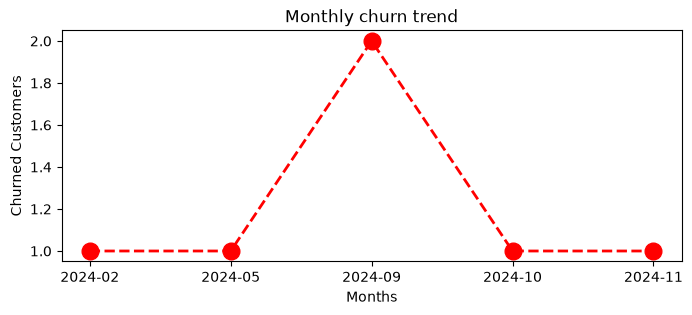

In [159]:
#4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_months'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual [df_visual['churn_flag'] == 1].groupby('cancellation_months').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='red', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title('Monthly churn trend')
plt.xlabel('Months')
plt.ylabel('Churned Customers')
plt.show()

<BarContainer object of 3 artists>

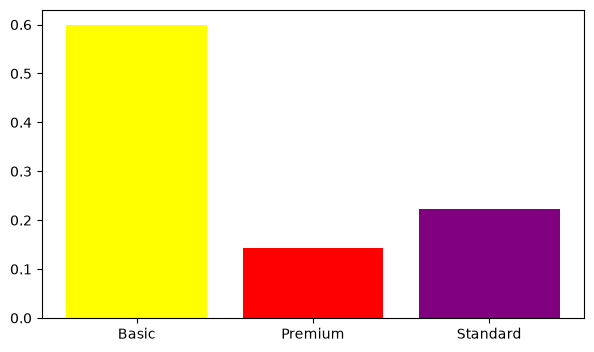

In [169]:
#4.2 Churn by Plan Type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['yellow', 'red', 'purple']
#random color ->
#colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)

In [171]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_months'],
      dtype='str')

<BarContainer object of 9 artists>

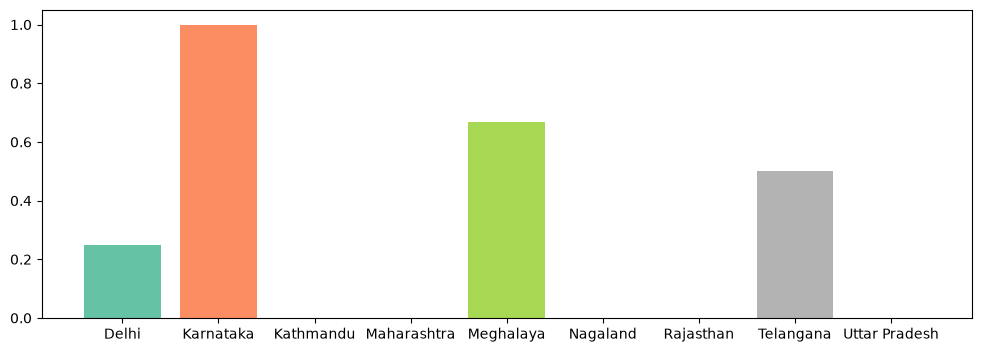

In [173]:
#4.3 Churn by States

churn_plan = df_visual.groupby('state')['churn_flag'].mean()


#random color ->
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)

In [ ]:
# Visualization using seaborn

In [174]:
# encoding- convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_months'],
      dtype='str')

In [184]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,0
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,0


In [188]:
df_visual['churn_risk'].unique()

<StringArray>
['low', 'high', 'medium']
Length: 3, dtype: str

In [204]:
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

order_mappings = {'plan_type' : ['Basic', 'Standard', 'Premium' ] ,
                  'contract_type' : ['Monthly','Annual'] ,
                  'churn_risk' : ['low', 'medium', 'high']
                 }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes
    

In [205]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,0


In [190]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,0


<Axes: >

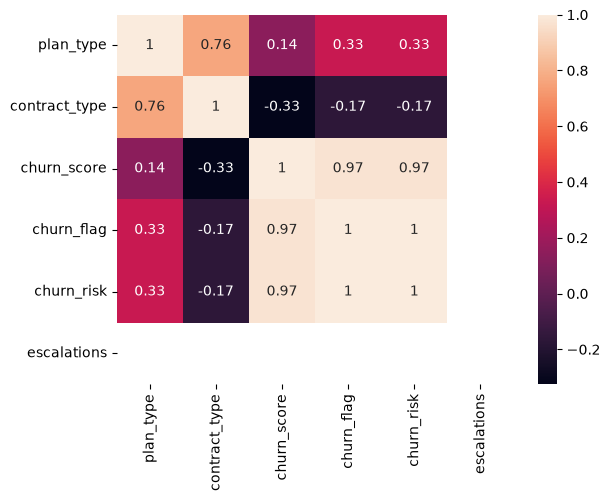

In [206]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

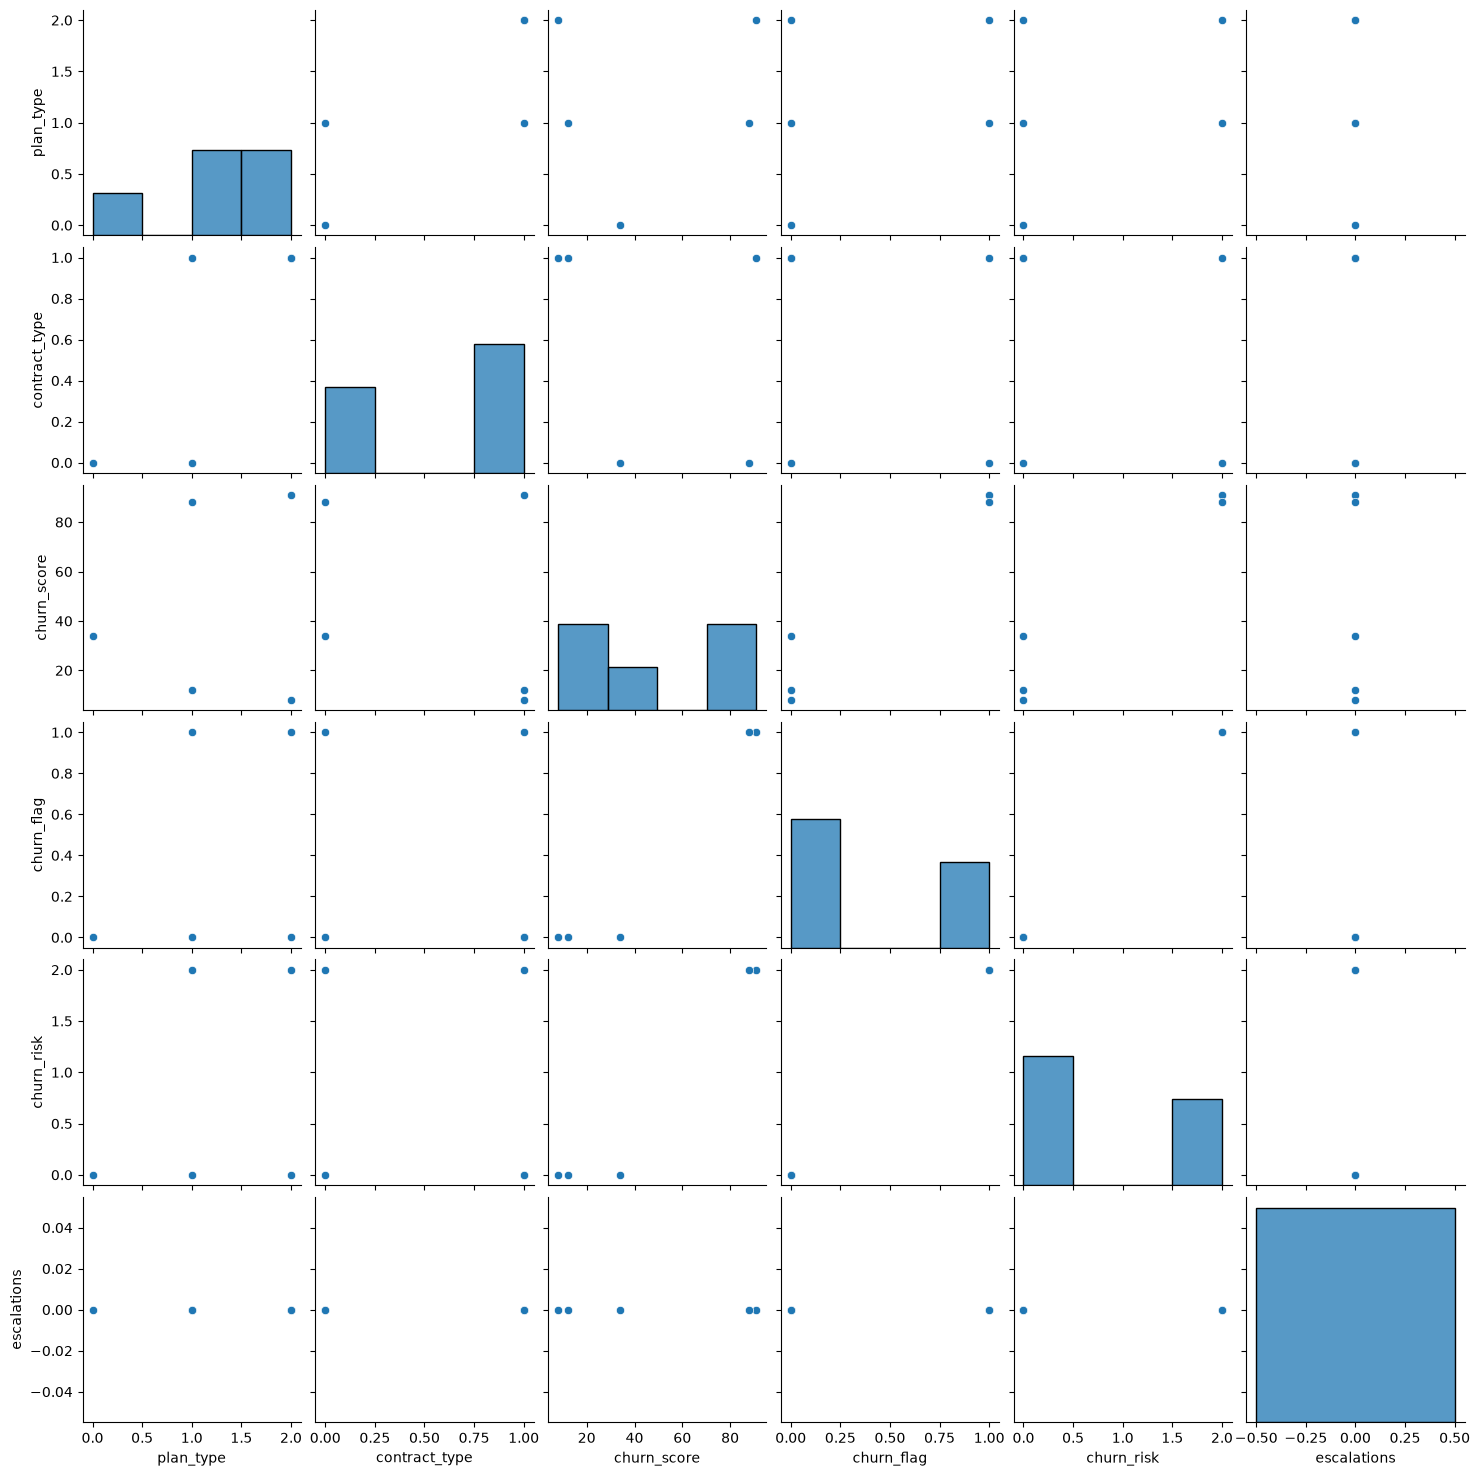

In [207]:
# Pair Plot - Relationship in a dataset
sns.pairplot(df_encoded)

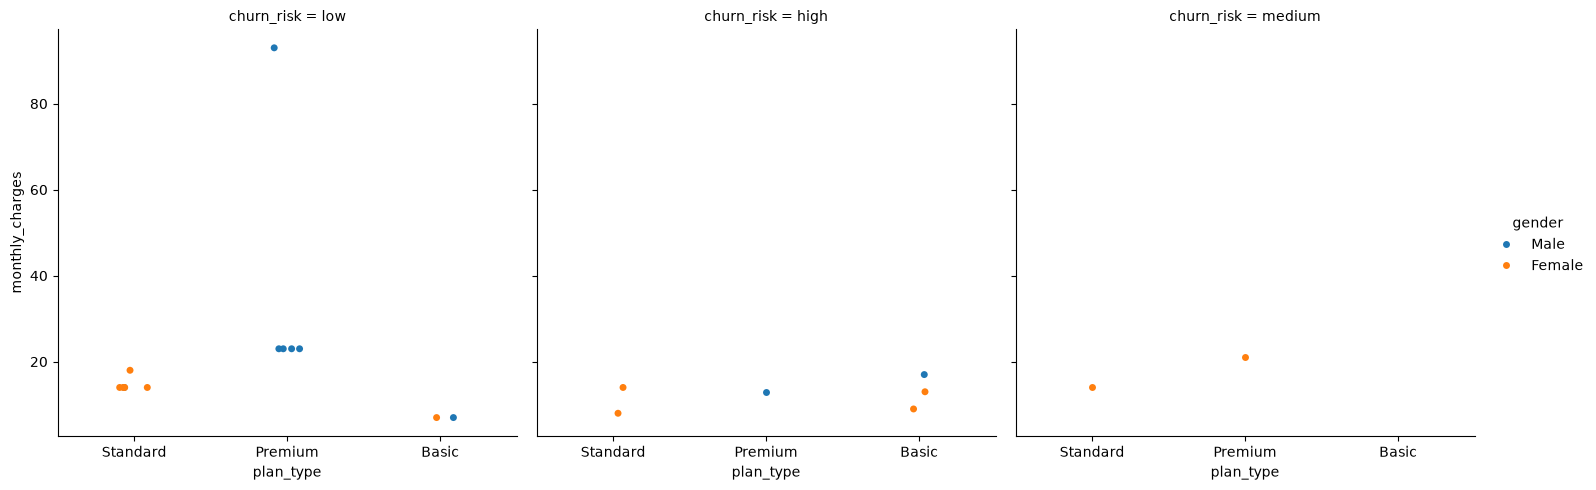

In [208]:
#catplot/Faceplot grid  -> Multi dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [213]:
# pivot table
pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [214]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_months'],
      dtype='str')

In [216]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=[ 'monthly_charges', 'customerid', 'churn_flag' ],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag': 'mean' 
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [ ]:
#SQL in python (pandas)

In [217]:
#create db in sql
conn = sqlite3.connect('test_database.sqlite')

#table generation
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

#commit and save
conn.commit()

In [224]:
#insert data

cursor = conn.cursor()

#sql query to insert records in db table
cursor.execute(
    """ 
          INSERT INTO users VALUES 
          ('Ayush', 'INDIA', 8000),
          ('Harsh', 'BANGKOK', 5000),
          ('Nikhil', 'INDIA', 8000)
    """
)

#commit and save
conn.commit()

print("Data inserted Successfully!")

Data inserted Successfully!


In [226]:
#check inserted data in sql
conn = sqlite3.connect('test_database.sqlite')
query = """ SELECT * FROM users """


df_result = pd.read_sql(query , conn)
df_result.head()

,first_name,country,budget
0,Ayush,INDIA,8000
1,Harsh,BANGKOK,5000
2,Nikhil,INDIA,8000


In [227]:
#aggregation
query = """  
        SELECT country, sum(budget) as total_budget
        FROM users
        GROUP BY country
"""
df_agg = pd.read_sql(query,conn)
df_agg.head()

,country,total_budget
0,BANGKOK,5000
1,INDIA,16000


In [229]:
#always close the conn once task is over
conn.close()